In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
!wget http://download.cdn.yandex.net/mystem/mystem-3.0-linux3.1-64bit.tar.gz
!tar -xvf mystem-3.0-linux3.1-64bit.tar.gz
!mv mystem /usr/local/bin/mystem
!chmod +x /usr/local/bin/mystem

--2025-06-29 14:01:51--  http://download.cdn.yandex.net/mystem/mystem-3.0-linux3.1-64bit.tar.gz
Resolving download.cdn.yandex.net (download.cdn.yandex.net)... 37.9.64.225, 2a02:6b8:23::225
Connecting to download.cdn.yandex.net (download.cdn.yandex.net)|37.9.64.225|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: http://cloudcdn-m9-2.cdn.yandex.net/download.cdn.yandex.net/mystem/mystem-3.0-linux3.1-64bit.tar.gz?lid=235 [following]
--2025-06-29 14:01:51--  http://cloudcdn-m9-2.cdn.yandex.net/download.cdn.yandex.net/mystem/mystem-3.0-linux3.1-64bit.tar.gz?lid=235
Resolving cloudcdn-m9-2.cdn.yandex.net (cloudcdn-m9-2.cdn.yandex.net)... 37.9.117.83, 2a02:6b8:c35:6:0:562:0:24
Connecting to cloudcdn-m9-2.cdn.yandex.net (cloudcdn-m9-2.cdn.yandex.net)|37.9.117.83|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16457938 (16M) [application/octet-stream]
Saving to: ‘mystem-3.0-linux3.1-64bit.tar.gz.1’

mystem-3.0-linux3.1 100%[=================

In [21]:
import pandas as pd #работа с таблицами
import numpy as np  #линейная алгебра: работа с векторами
from pymystem3 import Mystem
path_to_train_data = 'drive/My Drive/SFU 3/Ex ml/4_сентимент_анализ/Sentiment_analysis_data/'

In [22]:
# Read the data from CSV files
n = ['id', 'date','name','text','typr','rep','rtw','faw','stcount','foll','frien','listcount']
data_positive = pd.read_csv(path_to_train_data + 'positive.csv', sep=';',on_bad_lines='skip', names=n)
data_negative = pd.read_csv(path_to_train_data + 'negative.csv', sep=';',on_bad_lines='skip', names=n)

In [23]:
data_positive.head() #вывести первые 5 строк таблицы positive

,id,date,name,text,typr,rep,rtw,faw,stcount,foll,frien,listcount
0,408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
1,408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
2,408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0
3,408906695356973056,1386325927,ikonnikova_21,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,0,1,0,1549,19,17,0
4,408906761416867842,1386325943,JumpyAlex,@irina_dyshkant Вот что значит страшилка :D\nН...,1,0,0,0,597,16,23,1


In [24]:
data_negative.head() #вывести первые 5 строк таблицы negative

,id,date,name,text,typr,rep,rtw,faw,stcount,foll,frien,listcount
0,408906762813579264,1386325944,dugarchikbellko,на работе был полный пиддес :| и так каждое за...,-1,0,0,0,8064,111,94,2
1,408906818262687744,1386325957,nugemycejela,"Коллеги сидят рубятся в Urban terror, а я из-з...",-1,0,0,0,26,42,39,0
2,408906858515398656,1386325966,4post21,@elina_4post как говорят обещаного три года жд...,-1,0,0,0,718,49,249,0
3,408906914437685248,1386325980,Poliwake,"Желаю хорошего полёта и удачной посадки,я буду...",-1,0,0,0,10628,207,200,0
4,408906914723295232,1386325980,capyvixowe,"Обновил за каким-то лешим surf, теперь не рабо...",-1,0,0,0,35,17,34,0


In [25]:
print('Размер positive:', data_positive.shape)
print('Размер negative:', data_negative.shape)

Размер positive: (114911, 12)
Размер negative: (111923, 12)


In [26]:
# Create balanced dataset
sample_size = min(data_positive.shape[0], data_negative.shape[0]) #выбираем минимум из размеров
raw_data = pd.concat((data_positive[:sample_size],
                           data_negative[:sample_size]), axis=0) #объединяем в 1 датасет по строкам (axis=0)
print('Новый размер:', raw_data.shape)
raw_data.head()

Новый размер: (223846, 12)


,id,date,name,text,typr,rep,rtw,faw,stcount,foll,frien,listcount
0,408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
1,408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
2,408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0
3,408906695356973056,1386325927,ikonnikova_21,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,0,1,0,1549,19,17,0
4,408906761416867842,1386325943,JumpyAlex,@irina_dyshkant Вот что значит страшилка :D\nН...,1,0,0,0,597,16,23,1


In [27]:
raw_texts = raw_data['text'].values
labels = raw_data['typr'].values

**Предобработка данных
(со знаками препинания)**

In [28]:
import re
from pymystem3 import Mystem

myst = Mystem()

#Функция для предобаботки
def preprocess_texts(texts, lemmatize=False):
    texts = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','URL', texts)
    texts = re.sub('@[^\s]+','USER', texts)
    texts = texts.lower().replace("ё", "е")
    # text = re.sub('[^a-zA-Zа-яА-Я]+', ' ', text)  #исключаем все знаки препинания из модели
    texts = re.sub('([\(\:\)\?\!]+)', ' \g<1> ', texts)   #отделяем смайлики (:) от текста для учета в модели; подумать как улучшить регулярное выражение для учета сложных смайлов
    texts = re.sub('[^a-zA-Zа-яА-Я\(\:\)\?\!]+', ' ', texts) # оставляем смайлы в текста для учета в модели

    texts = re.sub(' +',' ', texts)
    texts = texts.strip()

    if lemmatize:
      return ''.join(myst.lemmatize(texts)).strip()
    return texts

In [29]:
data_w_punct = [preprocess_texts(texts, lemmatize=False) for texts in raw_texts]
data_w_punct

['user хоть я и школота но поверь у нас то же самое : d общество профилирующий предмет типа )',
 'да все таки он немного похож на него но мой мальчик все равно лучше : d',
 'rt user ну ты идиотка ) я испугалась за тебя !!!',
 'rt user кто то в углу сидит и погибает от голода а мы еще порции взяли хотя уже и так жрать не хотим : dd url',
 'user вот что значит страшилка : d но блин посмотрев все части у тебя создастся ощущение что авторы курили что то : d',
 'ну любишь или нет ? я не знаю кто ты бля : d url',
 'rt user ох : d ну это конечно же user чтобы у нее было много друзей ведь она такая мимими lt',
 'rt user у тебя есть ухажер ? нет мои уши не кто не жрет : d',
 'поприветствуем моего нового читателя user )',
 'теперь у меня есть частичка сиднея :) sydney sydneyoperahouse url',
 'люблю маму и папу !!!! а в остальное я так влюбляюсь привязываюсь )))',
 'rt user как то я забыла что вчера приехал из деревни наш котэня и испугалась когда он утром пришел ко мне общаться :) доброе у',
 'u

**Предобработка данных
(без знаков препинания)**

In [30]:
import re
from pymystem3 import Mystem

myst = Mystem()

#Функция для предобаботки
def preprocess_text(text, lemmatize=False):
    text = re.sub('((www\.[^\s]+)|(https?://[^\s]+))','URL', text)
    text = re.sub('@[^\s]+','USER', text)
    text = text.lower().replace("ё", "е")
    text = re.sub('[^a-zA-Zа-яА-Я]+', ' ', text)  #исключаем все знаки препинания из модели
    text = re.sub('([\(\:\)\?\!]+)', ' \g<1> ', text)   #отделяем смайлики (:) от текста для учета в модели; подумать как улучшить регулярное выражение для учета сложных смайлов
    text = re.sub('[^a-zA-Zа-яА-Я\(\:\)\?\!]+', ' ', text) # оставляем смайлы в текста для учета в модели

    text = re.sub(' +',' ', text)
    text = text.strip()


    if lemmatize:
      return ''.join(myst.lemmatize(text)).strip()
    return text

In [31]:
data_wo_punct = [preprocess_text(text, lemmatize=False) for text in raw_texts]
data_wo_punct

['user хоть я и школота но поверь у нас то же самое d общество профилирующий предмет типа',
 'да все таки он немного похож на него но мой мальчик все равно лучше d',
 'rt user ну ты идиотка я испугалась за тебя',
 'rt user кто то в углу сидит и погибает от голода а мы еще порции взяли хотя уже и так жрать не хотим dd url',
 'user вот что значит страшилка d но блин посмотрев все части у тебя создастся ощущение что авторы курили что то d',
 'ну любишь или нет я не знаю кто ты бля d url',
 'rt user ох d ну это конечно же user чтобы у нее было много друзей ведь она такая мимими lt',
 'rt user у тебя есть ухажер нет мои уши не кто не жрет d',
 'поприветствуем моего нового читателя user',
 'теперь у меня есть частичка сиднея sydney sydneyoperahouse url',
 'люблю маму и папу а в остальное я так влюбляюсь привязываюсь',
 'rt user как то я забыла что вчера приехал из деревни наш котэня и испугалась когда он утром пришел ко мне общаться доброе у',
 'user user user так было задумано да',
 'user д

**Обучение модели**

In [35]:
#модель с пунктуацией
from sklearn.naive_bayes import MultinomialNB   #импорт алгоритма NB из библиотеки sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer   #импорт алгоритмов построения "мешка слов" и преобразования весов согласно tf-idf

def tokenize_func(texts):       # можно сделать "умную функцию" разделения на токены (не только по пробелам)
  return texts.split(' ')

def tf_idf_vectorize(preprocessed_texts):
  count_vect = CountVectorizer(tokenizer=tokenize_func)
  counts = count_vect.fit_transform(preprocessed_texts)
  tfidf_transformer = TfidfTransformer()
  tfidf = tfidf_transformer.fit_transform(counts)
  return tfidf, count_vect, tfidf_transformer

vectorized_data, count_vect, tfidf_transformer = tf_idf_vectorize(data_w_punct) # возвращается (вектора, словарь)

from sklearn.model_selection import train_test_split   #импорт функции, которая разделит данные в указанной пропорции
x_train, x_test, y_train, y_test_w_punct = train_test_split(vectorized_data, labels, test_size=0.25, random_state=42)  # пропорция 25/75 - test/train  / x_train, x_test - тексты, y_train, y_test - labels

pos_train_cnt = len(y_train[y_train == 1])
neg_train_cnt = len(y_train[y_train == -1])

pos_test_cnt = len(y_test_w_punct[y_test_w_punct == 1])
neg_test_cnt = len(y_test_w_punct[y_test_w_punct == -1])

print('соотношение в train:', pos_train_cnt/neg_train_cnt)
print('соотношение в test:', pos_test_cnt/neg_test_cnt)

clf = MultinomialNB() #создание модели
clf.fit(x_train, y_train) #обучение модели в соответствии с разметкой labels

predicted_w_punct = clf.predict(x_test) #предскажем значения на test, т.е. какие будут labels по текстам
predicted_w_punct

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #импорт метрик
print('accuracy:', accuracy_score(y_test_w_punct, predicted_w_punct))  # доля правильных ответов модели на тестовой выборке: (кол-во правильных позитивных + правильных негативных) / (кол-во элементов тестовой выборки)
print('precision:', precision_score(y_test_w_punct, predicted_w_punct))  # точность: доля твитов, отнесенных к классу 1, которые действительно принадлежат классу 1 (насколько мы уверены в этом)
print('recall:', recall_score(y_test_w_punct, predicted_w_punct))    # полнота: доля твитов 1 класса, которые были отнесены к 1 классу (сколько алгоритм смог отнести)
print('F1-score:', f1_score(y_test_w_punct, predicted_w_punct))      # баланс точности и полноты

#сохранение модели в pkl
import pickle
import os

# Путь, куда сохраняются модели (можно изменить при необходимости)
save_path = 'drive/My Drive/SFU 3/Ex ml/4_сентимент_анализ/Sentiment_analysis_models/with_punct'
os.makedirs(save_path, exist_ok=True)

# Сохраняем модель с пунктуацией
with open(os.path.join(save_path, 'clf_with_punct.pkl'), 'wb') as f:
    pickle.dump(clf, f)  # clf — это модель после обучения на data_w_punct


# Сохраняем векторизатор
with open(os.path.join(save_path, 'count_vectorizer.pkl'), 'wb') as f:
    pickle.dump(count_vect, f)

with open(os.path.join(save_path, 'tfidf_transformer.pkl'), 'wb') as f:
    pickle.dump(tfidf_transformer, f)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


соотношение в train: 1.0026481850389475
соотношение в test: 0.9920973942759505
accuracy: 0.9676923626746721
precision: 0.9655591282600929
recall: 0.9697165410836024
F1-score: 0.9676333691371285


In [36]:
#модель без пунктуации
from sklearn.naive_bayes import MultinomialNB   #импорт алгоритма NB из библиотеки sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer   #импорт алгоритмов построения "мешка слов" и преобразования весов согласно tf-idf

def tokenize_func(text):       # можно сделать "умную функцию" разделения на токены (не только по пробелам)
  return text.split(' ')

def tf_idf_vectorize(preprocessed_texts):
    count_vect_no_punct = CountVectorizer(tokenizer=tokenize_func)
    counts = count_vect_no_punct.fit_transform(preprocessed_texts)
    tfidf_transformer_no_punct = TfidfTransformer()
    tfidf = tfidf_transformer_no_punct.fit_transform(counts)
    return tfidf, count_vect_no_punct, tfidf_transformer_no_punct

vectorized_data, count_vect_no_punct, tfidf_transformer_no_punct = tf_idf_vectorize(data_wo_punct) # возвращается (вектора, словарь)

from sklearn.model_selection import train_test_split   #импорт функции, которая разделит данные в указанной пропорции
x_train, x_test, y_train, y_test_wo_punct = train_test_split(vectorized_data, labels, test_size=0.25, random_state=42)  # пропорция 25/75 - test/train  / x_train, x_test - тексты, y_train, y_test - labels

pos_train_cnt = len(y_train[y_train == 1])
neg_train_cnt = len(y_train[y_train == -1])

pos_test_cnt = len(y_test_wo_punct[y_test_wo_punct == 1])
neg_test_cnt = len(y_test_wo_punct[y_test_wo_punct == -1])

print('соотношение в train:', pos_train_cnt/neg_train_cnt)
print('соотношение в test:', pos_test_cnt/neg_test_cnt)

clf = MultinomialNB() #создание модели
clf.fit(x_train, y_train) #обучение модели в соответствии с разметкой labels

predicted_wo_punct = clf.predict(x_test) #предскажем значения на test, т.е. какие будут labels по текстам
predicted_wo_punct

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #импорт метрик
print('accuracy:', accuracy_score(y_test_wo_punct, predicted_wo_punct))  # доля правильных ответов модели на тестовой выборке: (кол-во правильных позитивных + правильных негативных) / (кол-во элементов тестовой выборки)
print('precision:', precision_score(y_test_wo_punct, predicted_wo_punct))  # точность: доля твитов, отнесенных к классу 1, которые действительно принадлежат классу 1 (насколько мы уверены в этом)
print('recall:', recall_score(y_test_wo_punct, predicted_wo_punct))    # полнота: доля твитов 1 класса, которые были отнесены к 1 классу (сколько алгоритм смог отнести)
print('F1-score:', f1_score(y_test_wo_punct, predicted_wo_punct))      # баланс точности и полноты

#сохранение модели без пунктуации в pkl
import pickle
import os

# Путь, куда сохраняются модели (можно изменить при необходимости)
save_path = 'drive/My Drive/SFU 3/Ex ml/4_сентимент_анализ/Sentiment_analysis_models/wo_punct'
os.makedirs(save_path, exist_ok=True)
with open(os.path.join(save_path, 'clf_wo_punct.pkl'), 'wb') as f:
    pickle.dump(clf, f)  # clf — теперь после обучения на data_wo_punct

with open(os.path.join(save_path, 'count_vectorizer_no_punct.pkl'), 'wb') as f:
    pickle.dump(count_vect_no_punct, f)

with open(os.path.join(save_path, 'tfidf_transformer_no_punct.pkl'), 'wb') as f:
    pickle.dump(tfidf_transformer_no_punct, f)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


соотношение в train: 1.0026481850389475
соотношение в test: 0.9920973942759505
accuracy: 0.7569064722490261
precision: 0.7691901275567967
recall: 0.7313240043057051
F1-score: 0.7497792819305473


**Сравнение работы моделей**

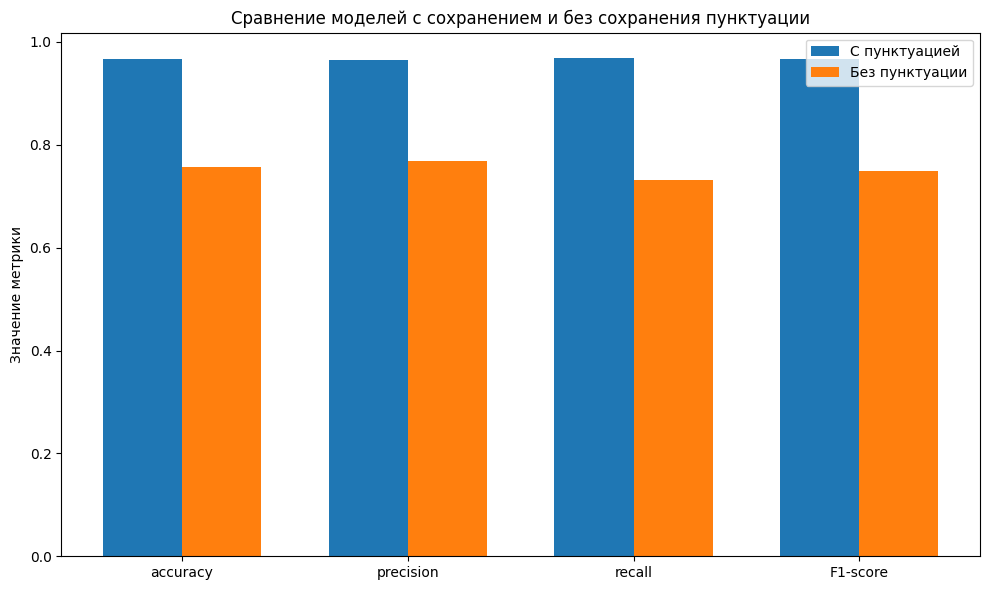

In [34]:
from os import WNOHANG
import matplotlib.pyplot as plt
import numpy as np

metrics = ['accuracy', 'precision', 'recall', 'F1-score']
w_punct = [
    accuracy_score(y_test_w_punct, predicted_w_punct),
    precision_score(y_test_w_punct, predicted_w_punct),
    recall_score(y_test_w_punct, predicted_w_punct),
    f1_score(y_test_w_punct, predicted_w_punct)
]
wo_punct = [
    accuracy_score(y_test_wo_punct, predicted_wo_punct),
    precision_score(y_test_wo_punct, predicted_wo_punct),
    recall_score(y_test_wo_punct, predicted_wo_punct),
    f1_score(y_test_wo_punct, predicted_wo_punct)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, w_punct, width, label='С пунктуацией')
rects2 = ax.bar(x + width/2, wo_punct, width, label='Без пунктуации')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей с сохранением и без сохранения пунктуации')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

fig.tight_layout()
plt.show()